# History matching of simulation models

We demonstrate history matching of a Direct Column Breakthrough (DCB) simulation model in Mocca.
We leverage the powerful and flexible optimization functionality of Jutul to set up and perform the history matching.
For more details about the DCB modelling, see the [Simulate DCB](simulate_DCB.md) example.

Import necessary modules

In [1]:
import Jutul
import Mocca

We create a function for setting up new simulation cases from the value of the parameter we wish to tune

In [2]:
function setup_case(prm, step_info=missing)

    param_dict_symb = Dict(Symbol(k) => v for (k, v) in prm)
    RealT = valtype(param_dict_symb)
    constants, info = Mocca.parse_input(Mocca.haghpanah_DCB_input(); typeT=RealT)

    for (k, v) in param_dict_symb
        print(k)
        print(v)
        setproperty!(constants, Symbol(k), v)
    end
    case,  = Mocca.setup_mocca_case(constants, info)

    return case
end;

# Create synthetic reference data

In [3]:
constants_ref, = Mocca.parse_input(Mocca.haghpanah_DCB_input(); typeT=Float64)

prm_ref = Dict("v_feed" => constants_ref.v_feed)
case_ref = setup_case(prm_ref);

v_feed0.37

Configure simulator which will be used in the history matching

In [4]:
timestep_selector_cfg = (y=0.01, Temperature=10.0, Pressure=10.0)
sim, cfg = Mocca.setup_process_simulator(case_ref.model, case_ref.state0, case_ref.parameters;
    timestep_selector_cfg = timestep_selector_cfg,
    initial_dt = 1.0,
    output_substates = true,
    info_level = -1
);

Run reference simulation to generate and generate "ground truth" data from the result

In [5]:
states, timesteps_out = Mocca.simulate_process(case_ref;
    simulator = sim,
    config = cfg
);

times_ref = cumsum(timesteps_out)
total_time = times_ref[end]
last_cell_idx = Jutul.number_of_cells(case_ref.model.domain)
qCO2_ref = map(s -> getindex(s[:AdsorbedConcentration], 1, last_cell_idx), states)
qCO2_ref_by_time = Jutul.get_1d_interpolator(times_ref, qCO2_ref);

# Setting up and solving the optimization problem
We define a suitable objective function to quantify the match between our simulations and the reference solution.
Here we choose deviation of adsorbed CO2 in the last grid cell.

In [6]:
function objective_function(model, state, dt, step_info, forces)
    current_time = step_info[:time]
    q_co2 = getindex(state[:AdsorbedConcentration], 1, last_cell_idx)
    q_co2_ref = qCO2_ref_by_time(current_time)
    v = dt/total_time*(q_co2 - q_co2_ref)^2
    return v
end;

Perturb the known parameter $v_{feed}$ to form our initial guess for the optimization

In [7]:
prm_guess = Dict("v_feed" => constants_ref.v_feed+0.2)

Dict{String, Float64} with 1 entry:
  "v_feed" => 0.57

Activate $v_{feed}$ as a free parameter

In [8]:
dprm = Jutul.DictOptimization.DictParameters(prm_guess)
Jutul.DictOptimization.free_optimization_parameter!(dprm, "v_feed"; rel_min = 0.1, rel_max = 10.0)

DictParameters with 1 parameters (1 active), and 0 multipliers:
Active optimization parameters
┌────────┬───────────────┬───────┬───────┬─────┐
│   Name │ Initial value │ Count │   Min │ Max │
├────────┼───────────────┼───────┼───────┼─────┤
│ v_feed │ 0.57          │     1 │ 0.057 │ 5.7 │
└────────┴───────────────┴───────┴───────┴─────┘
No inactive optimization parameters.
No multipliers set.


Run the optimization

In [9]:
prm_opt = Jutul.DictOptimization.optimize(dprm, objective_function, setup_case;
    config = cfg,
    max_it = 10,
    obj_change_tol = 1e-3
);

Optimization: Starting calibration of 1 parameters.
Optimization: Setting up adjoint storage.
Optimization: Finished setup in 28.18433368 seconds.
It.  | Objective  | Proj. grad | Linesearch-its
-----------------------------------------------
   0 | 7.6129e+05 | 2.6629e+07 | -
LBFGS: Resetting 'm' to number of parameters: m = 1
   1 | 7.4915e+03 | 2.6629e+07 | 2
   2 | 2.8822e+01 | 7.0900e+06 | 2
   3 | 1.0718e+01 | 4.5699e+05 | 1
LBFGS: Line search unable to succeed in 5 iterations ...
   4 | 3.5082e+00 | 4.7057e+04 | 5
   5 | 3.4878e+00 | 8.4036e+04 | 1
LBFGS: Line search unable to succeed in 5 iterations ...
LBFGS: Hessian not updated during iteration 6
   6 | 3.4878e+00 | 4.1567e+04 | 5
Optimization: Finished in 135.057565821 seconds.


We can see a clear reduction of the objective function value throughout the optimization iterations,
indicating a close match between the reference solution and our simulation.

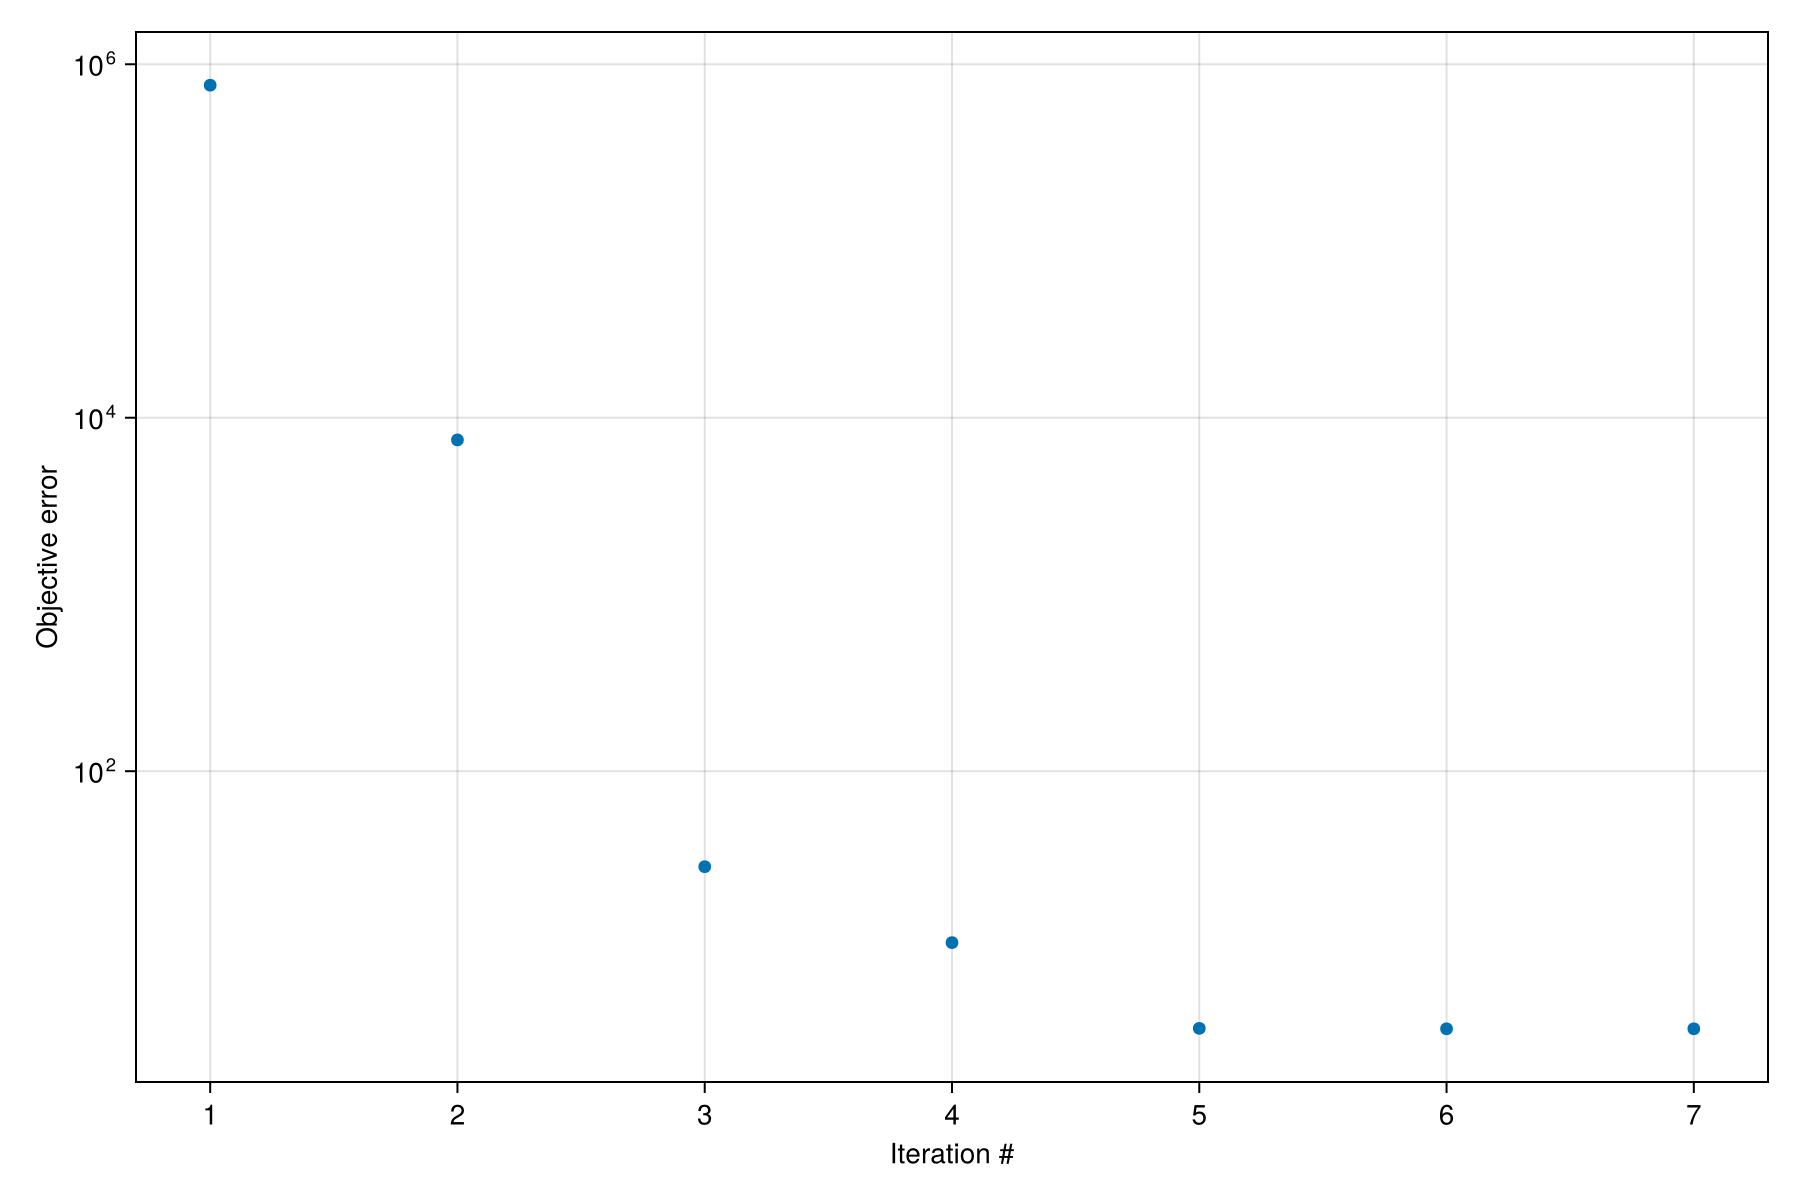

In [10]:
f = Mocca.plot_optimization_history(dprm)

We can look at the optimization result:

In [11]:
dprm

DictParameters with 1 parameters (1 active), and 0 multipliers:
Active optimization parameters
┌────────┬───────────────┬───────┬───────┬─────┬─────────────────┬────────┐
│   Name │ Initial value │ Count │   Min │ Max │ Optimized value │ Change │
├────────┼───────────────┼───────┼───────┼─────┼─────────────────┼────────┤
│ v_feed │ 0.57          │     1 │ 0.057 │ 5.7 │ 0.37            │ -35.0% │
└────────┴───────────────┴───────┴───────┴─────┴─────────────────┴────────┘
No inactive optimization parameters.
No multipliers set.


and see that the value matches the reference parameter value

In [12]:
constants_ref.v_feed

0.37

## Example on GitHub
If you would like to run this example yourself, it can be downloaded from [the Mocca.jl GitHub repository](https://github.com/sintefmath/Mocca.jl/blob/main/examples/history_matching.jl).

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*